# Entrega 1 — Análise Comparativa de Representações
**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

Objetivo: comparar representações **esparsas** (Bag-of-Words e TF-IDF) com representações **densas** (embeddings) nas 40 manifestações, medindo a similaridade de cosseno em três pares escolhidos pelo enunciado:

| Par | Esperado |
|---|---|
| M003 (buraco na Av. Brasil) × M017 (asfalto esburacado da avenida principal) | **Alta**: mesmo problema, palavras diferentes |
| M008 (posto de saúde sem médico) × M022 (falta atendimento no PSF) | **Alta**: mesmo problema, palavras diferentes |
| M008 (posto de saúde sem médico) × M031 (lâmpada queimada na praça) | **Baixa**: temas diferentes |

In [1]:
import json
import os
import warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # evita aviso do joblib no Windows
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

with open("data/manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)
df = pd.DataFrame(manifestacoes)
idx = {m: i for i, m in enumerate(df["id"])}
print(df.shape)
df.head()

(40, 4)


,id,data,categoria_oficial,texto
0,M001,2026-03-02,infraestrutura,"Calçada toda quebrada na Rua das Flores, perto do número 120. Dois idosos já caíram tentando passar por ali e ningué..."
1,M002,2026-03-02,saúde,Fiquei mais de cinco horas esperando atendimento na UPA do Centro com meu filho de dois anos com febre alta. Só havi...
2,M003,2026-03-03,infraestrutura,"Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estouraram o pneu e um mot..."
3,M004,2026-03-03,segurança,"Os moradores da Rua Sete estão com medo porque aconteceram três assaltos nesta semana na esquina da padaria, sempre ..."
4,M005,2026-03-04,infraestrutura,A Rua Pernambuco está completamente escura à noite porque os postes de iluminação estão apagados há mais de um mês.


## 1) Pré-processamento comum às representações esparsas
Minúsculas, remoção de acentos (`strip_accents='unicode'`) e de stopwords em português.

In [2]:
STOPWORDS_PT = """a o as os um uma uns umas de do da dos das em no na nos nas por pelo pela pelos pelas
para pra com sem e ou mas que se ao aos ate sobre entre ser sao foi era esta estao ha tem ter nao ja muito mais
seu sua seus suas este esta esse essa isso isto como quando onde qual eu meu minha nos gente la ali ninguem
todo toda todos todas outro outra dia vez vezes""".split()

## 2) Bag-of-Words (contagem de termos)

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow = CountVectorizer(strip_accents="unicode", stop_words=STOPWORDS_PT)
X_bow = bow.fit_transform(df["texto"])
print(f"Vocabulário BoW: {len(bow.vocabulary_)} termos")
print(f"Matriz BoW: {X_bow.shape} | densidade: {X_bow.nnz / np.prod(X_bow.shape):.2%}")

Vocabulário BoW: 529 termos
Matriz BoW: (40, 529) | densidade: 3.40%


## 3) TF-IDF

In [4]:
tfidf = TfidfVectorizer(strip_accents="unicode", stop_words=STOPWORDS_PT)
X_tfidf = tfidf.fit_transform(df["texto"])
print(f"Matriz TF-IDF: {X_tfidf.shape} | densidade: {X_tfidf.nnz / np.prod(X_tfidf.shape):.2%}")

Matriz TF-IDF: (40, 529) | densidade: 3.40%


## 4) Embeddings densos (dois modelos)
- `paraphrase-multilingual-MiniLM-L12-v2`: multilíngue, treinado para paráfrases (inclui português).
- `all-MiniLM-L6-v2`: treinado principalmente em inglês, usado como comparação.

In [5]:
MODELOS = {
    "Emb. multilíngue (MiniLM-L12)": "paraphrase-multilingual-MiniLM-L12-v2",
    "Emb. inglês (all-MiniLM-L6)": "sentence-transformers/all-MiniLM-L6-v2",
}
X_emb = {}
for rotulo, nome in MODELOS.items():
    X_emb[rotulo] = SentenceTransformer(nome).encode(df["texto"].tolist(), normalize_embeddings=True)
    print(f"{rotulo}: {X_emb[rotulo].shape} | densidade: {(X_emb[rotulo] != 0).mean():.2%}")

Emb. multilíngue (MiniLM-L12): (40, 384) | densidade: 100.00%


Emb. inglês (all-MiniLM-L6): (40, 384) | densidade: 100.00%


## 5) Similaridade de cosseno nos três pares

In [6]:
PARES = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]

def cos(X, a, b):
    return float(cosine_similarity(X[idx[a]].reshape(1, -1) if not hasattr(X, "tocsr") else X[idx[a]],
                                   X[idx[b]].reshape(1, -1) if not hasattr(X, "tocsr") else X[idx[b]])[0, 0])

linhas = []
for a, b in PARES:
    linha = {"Par": f"{a} × {b}", "BoW": cos(X_bow, a, b), "TF-IDF": cos(X_tfidf, a, b)}
    for rotulo, X in X_emb.items():
        linha[rotulo] = cos(X, a, b)
    linhas.append(linha)
tabela = pd.DataFrame(linhas).set_index("Par").round(3)
tabela

,BoW,TF-IDF,Emb. multilíngue (MiniLM-L12),Emb. inglês (all-MiniLM-L6)
Par,,,,
M003 × M017,0.069,0.051,0.626,0.542
M008 × M022,0.000,0.000,0.674,0.554
M008 × M031,0.000,0.000,0.125,0.480


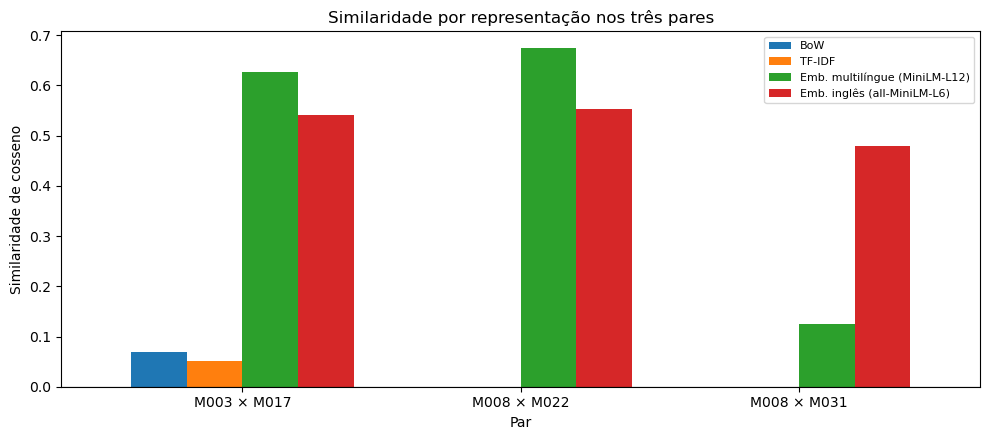

In [7]:
ax = tabela.plot(kind="bar", figsize=(10, 4.5), rot=0, width=0.8)
ax.set_ylabel("Similaridade de cosseno")
ax.set_title("Similaridade por representação nos três pares")
ax.axhline(0, color="black", lw=0.8)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 6) Por que BoW e TF-IDF erram? Termos em comum em cada par

In [8]:
analisador = bow.build_analyzer()
for a, b in PARES:
    ta, tb = set(analisador(df.loc[idx[a], "texto"])), set(analisador(df.loc[idx[b], "texto"]))
    print(f"{a} × {b}")
    print(f"   {a}: {df.loc[idx[a], 'texto']}")
    print(f"   {b}: {df.loc[idx[b], 'texto']}")
    print(f"   termos em comum: {sorted(ta & tb) or 'nenhum'}\n")

M003 × M017
   M003: Tem um buraco enorme na Av. Brasil, em frente ao supermercado Bom Preço. Vários carros já estouraram o pneu e um motociclista caiu ontem.
   M017: O asfalto todo esburacado da avenida principal está causando acidentes. Precisa de recapeamento urgente, os carros desviam dos buracos e invadem a outra pista.
   termos em comum: ['carros']

M008 × M022
   M008: O posto de saúde do Jardim América está sem médico há duas semanas. As pessoas vão até lá e voltam para casa sem consulta.
   M022: Falta atendimento no PSF do meu bairro. Não tem doutor para consultar e mandam a gente voltar outro dia, mas no outro dia também não tem.
   termos em comum: nenhum

M008 × M031
   M008: O posto de saúde do Jardim América está sem médico há duas semanas. As pessoas vão até lá e voltam para casa sem consulta.
   M031: Lâmpada queimada na praça do bairro Boa Vista. A praça fica escura e perigosa à noite e os moradores deixaram de usar o espaço.
   termos em comum: nenhum



## 7) Visão geral: similaridade média dentro e fora da mesma categoria oficial
Se a representação captura o tema, pares da **mesma** categoria devem ter similaridade maior que pares de categorias **diferentes**.

In [9]:
mesma = df["categoria_oficial"].values[:, None] == df["categoria_oficial"].values[None, :]
fora_diag = ~np.eye(len(df), dtype=bool)
reps = {"BoW": X_bow, "TF-IDF": X_tfidf, **X_emb}
resumo = []
for nome, X in reps.items():
    S = cosine_similarity(X)
    m_in, m_out = S[mesma & fora_diag].mean(), S[~mesma].mean()
    resumo.append({"Representação": nome, "Média mesma categoria": m_in,
                   "Média categorias diferentes": m_out, "Separação (diferença)": m_in - m_out})
pd.DataFrame(resumo).round(3)

,Representação,Média mesma categoria,Média categorias diferentes,Separação (diferença)
0,BoW,0.068,0.022,0.046
1,TF-IDF,0.044,0.014,0.030
2,Emb. multilíngue (MiniLM-L12),0.416,0.217,0.199
3,Emb. inglês (all-MiniLM-L6),0.518,0.462,0.056


## 8) Conclusão

**Resultados (cosseno):**

| Par | BoW | TF-IDF | Emb. multilíngue | Emb. inglês |
|---|---|---|---|---|
| M003 × M017 (buraco × asfalto esburacado) | 0,069 | 0,051 | **0,626** | 0,542 |
| M008 × M022 (posto sem médico × falta atendimento no PSF) | 0,000 | 0,000 | **0,674** | 0,554 |
| M008 × M031 (posto sem médico × lâmpada queimada) | 0,000 | 0,000 | **0,125** | 0,480 |

**BoW e TF-IDF** só enxergam palavras idênticas. M008 e M022 falam do mesmo problema, mas não têm **nenhum** termo em comum ("médico" × "doutor", "posto de saúde" × "PSF", "consulta" × "consultar"), e a similaridade é exatamente zero, a mesma do par sem relação M008 × M031. Em M003 × M017 o único termo compartilhado é "carros"; "buraco" e "buracos"/"esburacado" contam como palavras diferentes. O TF-IDF ainda reduz esse valor porque pondera pela raridade, mas não resolve o problema de fundo: representações esparsas (3,4% de densidade aqui) não têm noção de sinônimo nem de flexão. Com elas, as duplicatas da ouvidoria passam despercebidas, exatamente o problema relatado pela prefeitura.

**Embeddings multilíngues** acertam os três casos: 0,63 e 0,67 nos pares que descrevem o mesmo problema e 0,13 no par sem relação, uma margem de mais de 0,5. Na visão geral, a similaridade média entre manifestações da mesma categoria (0,42) é quase o dobro da média entre categorias diferentes (0,22), sinal de que o espaço vetorial organiza os textos por tema.

**O modelo em inglês** (`all-MiniLM-L6-v2`) mostra que o modelo importa: ele dá 0,48 para posto de saúde × lâmpada queimada, quase o mesmo valor dos pares duplicados, e separa pouco as categorias (0,52 × 0,46). Como não foi treinado em português, quebra as palavras em pedaços de subpalavra sem significado e acaba aproximando qualquer texto em português.

**Limitações:** BoW e TF-IDF são rápidos, interpretáveis e úteis para termos exatos (nomes de ruas, protocolos), mas falham com sinônimos, siglas (PSF) e flexões. Embeddings capturam o significado, mas dependem do idioma do modelo, custam mais para calcular e não explicam por que dois textos são parecidos. Para a triagem da ouvidoria, a escolha é um **modelo multilíngue**, possivelmente combinado com busca léxica para nomes de logradouros.